In [1]:
!pip install datasets torch torchvision matplotlib ultralytics opencv-python


[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from datasets import load_dataset

path = r"D:\OneDrive\Desktop\dog face model\train-00000-of-00001.parquet"

ds = load_dataset("parquet", data_files=path)
print(ds)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 8363
    })
})


In [3]:
import os, time, json, random, hashlib
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ---- config ----
MIN_PHOTOS_PER_DOG = 3
IMG_SIZE           = 160     # 224 -> 160 makes CPU training ~2x faster
EMBEDDING_SIZE     = 128
TRIPLET_MARGIN     = 0.4     # was 0.2
LEARNING_RATE      = 1e-4
BATCH_SIZE         = 32      # was 16
EPOCHS             = 8       # was 5
PATIENCE           = 3
YOLO_CONF          = 0.50

plt.rcParams['figure.dpi'] = 110
print(f'IMG_SIZE {IMG_SIZE} | BATCH {BATCH_SIZE} | EPOCHS {EPOCHS} | MARGIN {TRIPLET_MARGIN}')

IMG_SIZE 160 | BATCH 32 | EPOCHS 8 | MARGIN 0.4


In [4]:
train = ds["train"]

labels = train["label"]
unique_dogs = set(labels)

print("Total photos:", len(train))
print("Number of dogs:", len(unique_dogs))
print("Average photos per dog:", round(len(train) / len(unique_dogs), 2))

Total photos: 8363
Number of dogs: 1393
Average photos per dog: 6.0


In [5]:
import pandas as pd

df = pd.DataFrame({"label": train["label"]})

print("--- HEAD ---")
print(df.head(10))

print("\n--- TAIL ---")
print(df.tail(10))

--- HEAD ---
   label
0      0
1      0
2      0
3      0
4      0
5      1
6      1
7      1
8      1
9      1

--- TAIL ---
      label
8353   1391
8354   1391
8355   1391
8356   1391
8357   1392
8358   1392
8359   1392
8360   1392
8361   1392
8362   1392


In [6]:
counts = df["label"].value_counts()

print("Most photos:", counts.max())
print("Least photos:", counts.min())
print("\nDistribution:")
print(counts.describe())

Most photos: 41
Least photos: 2

Distribution:
count    1393.000000
mean        6.003589
std         3.620561
min         2.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        41.000000
Name: count, dtype: float64


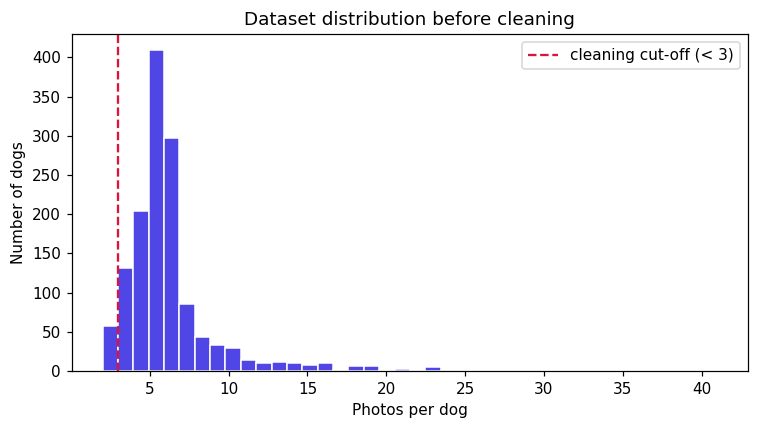

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(counts.values, bins=40, color='#4F46E5', edgecolor='white')
ax.axvline(MIN_PHOTOS_PER_DOG, color='crimson', linestyle='--',
           label=f'cleaning cut-off (< {MIN_PHOTOS_PER_DOG})')
ax.set_xlabel('Photos per dog'); ax.set_ylabel('Number of dogs')
ax.set_title('Dataset distribution before cleaning')
ax.legend(); plt.tight_layout()
plt.savefig('chart_dataset_distribution.png', bbox_inches='tight')
plt.show()

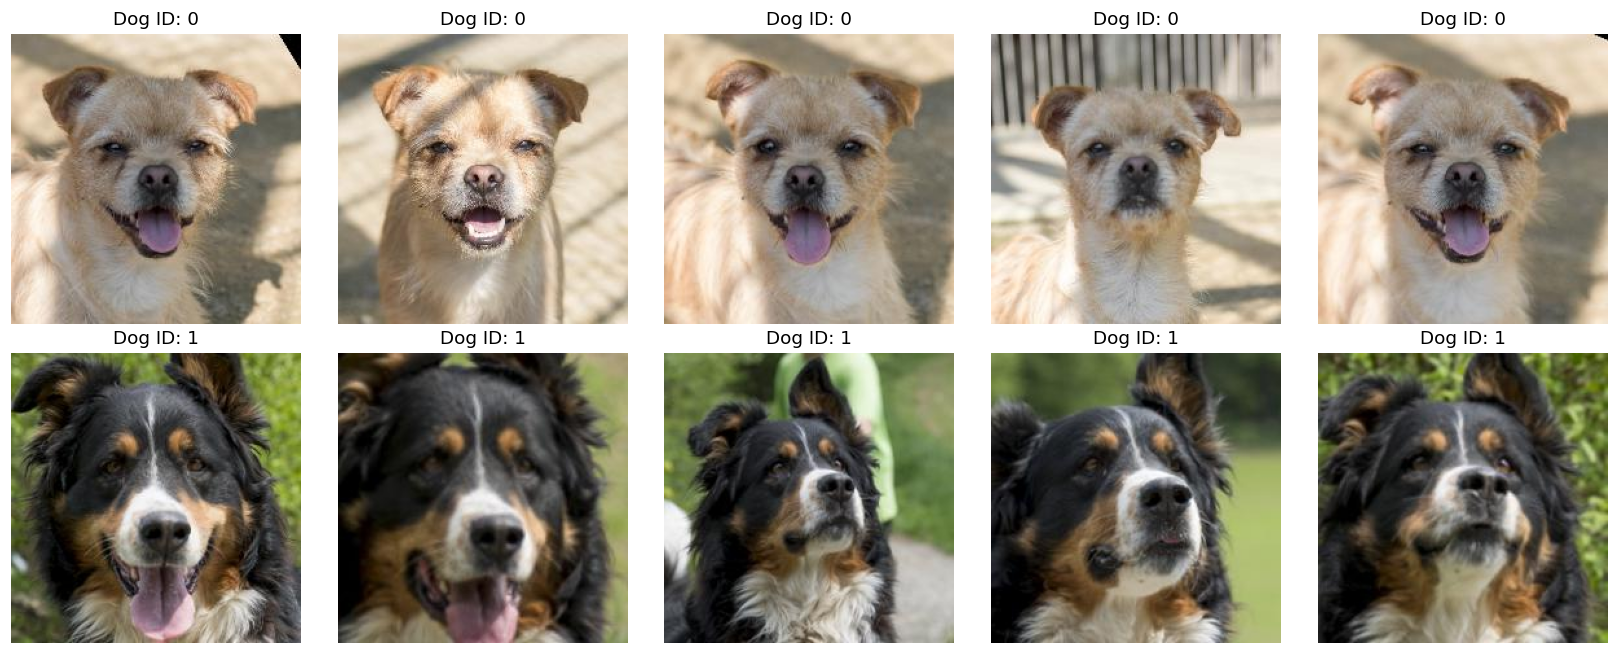

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(train[i]["image"])
    ax.set_title(f"Dog ID: {train[i]['label']}")
    ax.axis("off")
plt.tight_layout()
plt.savefig('chart_sample_images.png', bbox_inches='tight')
plt.show()

In [9]:
#Data Cleaning / Preparation

few_photos = counts[counts < MIN_PHOTOS_PER_DOG]
print(f"Dogs with fewer than {MIN_PHOTOS_PER_DOG} photos:", len(few_photos))
print("Photos affected:", few_photos.sum())

Dogs with fewer than 3 photos: 57
Photos affected: 114


In [10]:
img = train[0]["image"]
print("Type:", type(img))
print("Size:", img.size)
print("Mode:", img.mode)

Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Size: (224, 224)
Mode: RGB


In [11]:
#Duplicate/corrupt check

sizes = set()
for i in range(0, len(train), 500):
    sizes.add(train[i]["image"].size)
print("Different sizes found:", sizes)

# ---- added: real duplicate + corrupt scan ----
print("\nScanning every image for corruption and duplicates...")
corrupt, hashes, duplicates = [], {}, []

for i in range(len(train)):
    im = train[i]["image"]
    if im.mode != "RGB":
        corrupt.append((i, im.mode))
    h = hashlib.md5(np.array(im).tobytes()).hexdigest()
    if h in hashes:
        duplicates.append((hashes[h], i, labels[hashes[h]], labels[i]))
    else:
        hashes[h] = i
    if i % 2000 == 0 and i > 0:
        print(f"  {i}/{len(train)}")

cross_label = [d for d in duplicates if d[2] != d[3]]

print(f"\nCorrupt / non-RGB     : {len(corrupt)}")
print(f"Exact duplicates      : {len(duplicates)}")
print(f"Duplicates across IDs : {len(cross_label)}   <- label noise")
print(f"Null labels           : {sum(1 for l in labels if l is None)}")

Different sizes found: {(224, 224)}

Scanning every image for corruption and duplicates...
  2000/8363
  4000/8363
  6000/8363
  8000/8363

Corrupt / non-RGB     : 0
Exact duplicates      : 0
Duplicates across IDs : 0   <- label noise
Null labels           : 0


In [12]:
# Apply both cleaning rules - v1 identified these but never removed them

keep_dogs    = set(counts[counts >= MIN_PHOTOS_PER_DOG].index)
keep_indices = [i for i, l in enumerate(labels) if l in keep_dogs]
print(f"1. Removed {len(few_photos)} dogs with < {MIN_PHOTOS_PER_DOG} photos "
      f"({few_photos.sum()} photos)")

dupe_indices = {b for _, b, _, _ in duplicates}
before = len(keep_indices)
keep_indices = [i for i in keep_indices if i not in dupe_indices]
print(f"2. Removed {before - len(keep_indices)} duplicate photos")

final_dogs = set(labels[i] for i in keep_indices)
print(f"\nAFTER CLEANING: {len(keep_indices)} photos, {len(final_dogs)} dogs")
print(f"Total removed : {len(train) - len(keep_indices)} photos")

1. Removed 57 dogs with < 3 photos (114 photos)
2. Removed 0 duplicate photos

AFTER CLEANING: 8249 photos, 1336 dogs
Total removed : 114 photos


In [13]:
from ultralytics import YOLO
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(os.cpu_count())

yolo = YOLO(r"D:\OneDrive\Desktop\yoshi\dog face model\yolov8n.pt")
yolo.to(DEVICE)
print("Device:", DEVICE)
print("CPU threads:", torch.get_num_threads())

Device: cpu
CPU threads: 16



0: 640x640 1 dog, 1 sports ball, 313.6ms
Speed: 22.7ms preprocess, 313.6ms inference, 33.3ms postprocess per image at shape (1, 3, 640, 640)
Found: dog | Confidence: 0.59 | Box: [0, 22, 196, 222]
Found: sports ball | Confidence: 0.26 | Box: [97, 135, 132, 170]


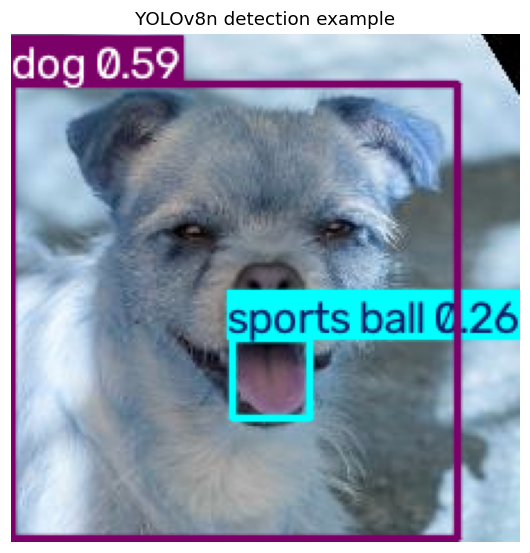

In [14]:
sample = train[0]["image"]
img_array = np.array(sample)

results = yolo(img_array)
for box in results[0].boxes:
    cls_name = yolo.names[int(box.cls)]
    conf = float(box.conf)
    coords = [round(c) for c in box.xyxy[0].tolist()]
    print(f"Found: {cls_name} | Confidence: {conf:.2f} | Box: {coords}")

annotated = results[0].plot()
plt.figure(figsize=(6, 6))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.title("YOLOv8n detection example")
plt.savefig('chart_yolo_detection.png', bbox_inches='tight')
plt.show()

In [15]:
from PIL import Image

def detect_and_crop_dog(image_array, min_confidence=YOLO_CONF):
    results = yolo(image_array, verbose=False)

    best_box = None
    best_conf = 0

    for box in results[0].boxes:
        cls_name = yolo.names[int(box.cls)]
        conf = float(box.conf)
        if cls_name == "dog" and conf > best_conf and conf >= min_confidence:
            best_conf = conf
            best_box = box.xyxy[0].tolist()

    if best_box is None:
        return None, 0

    x1, y1, x2, y2 = [max(0, int(v)) for v in best_box]
    crop = image_array[y1:y2, x1:x2]
    if crop.size == 0:
        return None, 0
    return crop, best_conf

print("detect_and_crop_dog ready")

detect_and_crop_dog ready


In [16]:
# Crop every image ONCE and cache it.
# v1 trained on full photos but production runs on YOLO crops - a train/serve
# mismatch. Cropping here fixes that, and caching removes the JPEG decode that
# made v1 take 28 min/epoch.

print(f"Cropping {len(keep_indices)} images...")
start = time.time()

cached_imgs   = np.zeros((len(keep_indices), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
cached_labels = np.zeros(len(keep_indices), dtype=np.int64)
yolo_confs, detected = [], 0

for n, idx in enumerate(keep_indices):
    arr = np.array(train[idx]["image"].convert("RGB"))
    crop, conf = detect_and_crop_dog(arr)
    if crop is None:
        crop = arr                    # fall back to the full photo
    else:
        detected += 1
        yolo_confs.append(conf)

    cached_imgs[n]   = np.array(Image.fromarray(crop).resize((IMG_SIZE, IMG_SIZE),
                                                             Image.BILINEAR))
    cached_labels[n] = labels[idx]

    if n % 250 == 0 and n > 0:
        el  = (time.time() - start) / 60
        eta = el / n * (len(keep_indices) - n)
        print(f"  {n}/{len(keep_indices)} | {el:.1f} min elapsed | ~{eta:.1f} min left")

mins = (time.time() - start) / 60
print(f"\nDone in {mins:.1f} min")
print(f"Dog detected : {detected}/{len(keep_indices)} ({detected/len(keep_indices)*100:.1f}%)")
print(f"Mean conf    : {np.mean(yolo_confs):.4f}")
print(f"Cache size   : {cached_imgs.nbytes/1024**3:.2f} GB")

np.savez_compressed("cached_crops.npz", imgs=cached_imgs, labels=cached_labels)
print("Saved cached_crops.npz")

Cropping 8249 images...
  250/8249 | 0.4 min elapsed | ~13.7 min left
  500/8249 | 0.8 min elapsed | ~12.4 min left
  750/8249 | 1.2 min elapsed | ~11.8 min left
  1000/8249 | 1.6 min elapsed | ~11.7 min left
  1250/8249 | 2.1 min elapsed | ~11.5 min left
  1500/8249 | 2.5 min elapsed | ~11.2 min left
  1750/8249 | 2.9 min elapsed | ~10.8 min left
  2000/8249 | 3.3 min elapsed | ~10.3 min left
  2250/8249 | 3.7 min elapsed | ~9.9 min left
  2500/8249 | 4.1 min elapsed | ~9.5 min left
  2750/8249 | 4.5 min elapsed | ~9.0 min left
  3000/8249 | 4.9 min elapsed | ~8.5 min left
  3250/8249 | 5.2 min elapsed | ~8.1 min left
  3500/8249 | 5.6 min elapsed | ~7.6 min left
  3750/8249 | 6.0 min elapsed | ~7.2 min left
  4000/8249 | 6.3 min elapsed | ~6.7 min left
  4250/8249 | 6.8 min elapsed | ~6.4 min left
  4500/8249 | 7.2 min elapsed | ~6.0 min left
  4750/8249 | 7.6 min elapsed | ~5.6 min left
  5000/8249 | 7.9 min elapsed | ~5.2 min left
  5250/8249 | 8.3 min elapsed | ~4.8 min left
  550

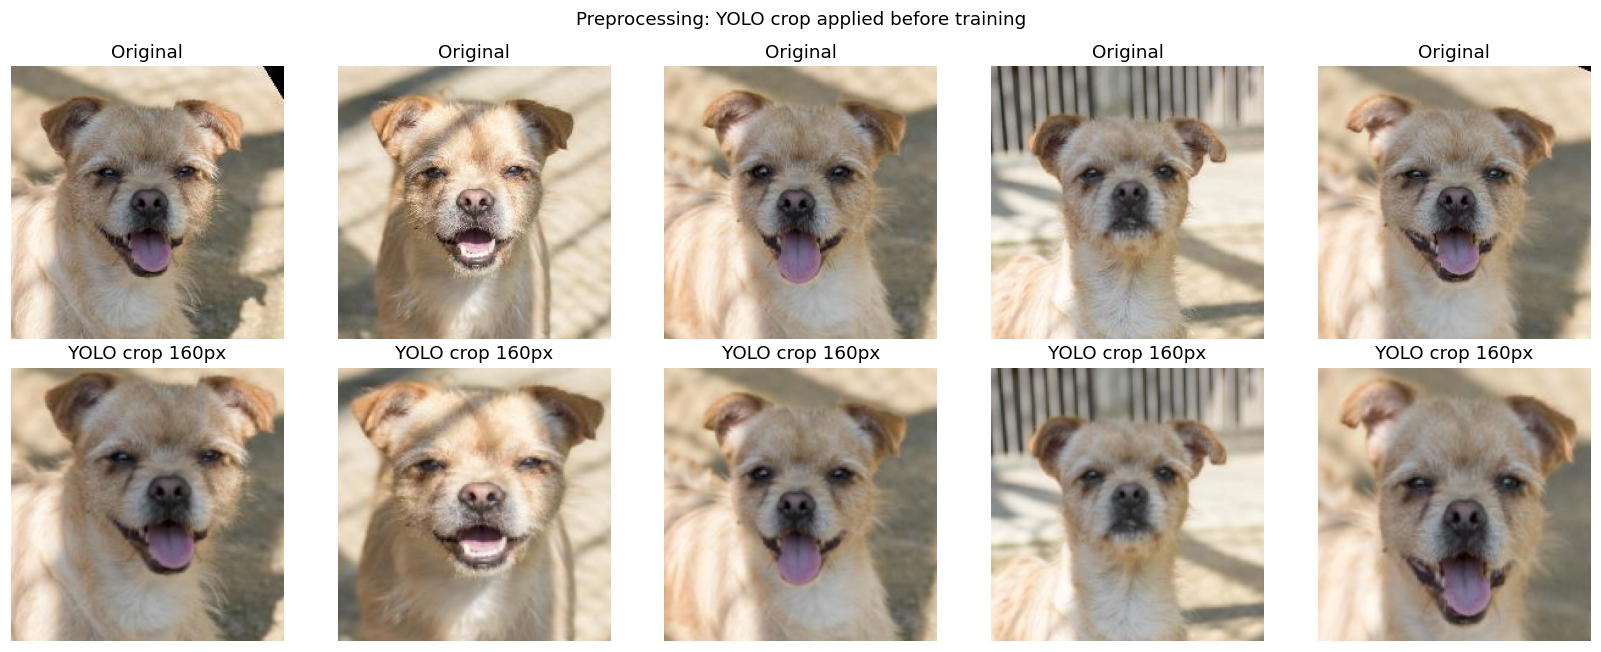

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(train[keep_indices[i]]["image"])
    axes[0, i].set_title("Original"); axes[0, i].axis("off")
    axes[1, i].imshow(cached_imgs[i])
    axes[1, i].set_title(f"YOLO crop {IMG_SIZE}px"); axes[1, i].axis("off")
plt.suptitle("Preprocessing: YOLO crop applied before training")
plt.tight_layout()
plt.savefig('chart_crop_comparison.png', bbox_inches='tight')
plt.show()

In [18]:
#Train / Val / Test Split
import random

random.seed(42)

all_dogs = sorted(set(cached_labels.tolist()))
random.shuffle(all_dogs)

n_train = int(len(all_dogs) * 0.70)     # v1 was 0.80 with no validation set
n_val   = int(len(all_dogs) * 0.10)

train_dogs = set(all_dogs[:n_train])
val_dogs   = set(all_dogs[n_train:n_train + n_val])
test_dogs  = set(all_dogs[n_train + n_val:])

print("Train dogs:", len(train_dogs))
print("Val dogs:", len(val_dogs))
print("Test dogs:", len(test_dogs))
print("Overlap (must all be 0):",
      len(train_dogs & val_dogs), len(train_dogs & test_dogs), len(val_dogs & test_dogs))

Train dogs: 935
Val dogs: 133
Test dogs: 268
Overlap (must all be 0): 0 0 0


In [19]:
train_indices = [i for i, l in enumerate(cached_labels) if l in train_dogs]
val_indices   = [i for i, l in enumerate(cached_labels) if l in val_dogs]
test_indices  = [i for i, l in enumerate(cached_labels) if l in test_dogs]

print("Train photos:", len(train_indices))
print("Val photos:", len(val_indices))
print("Test photos:", len(test_indices))
print("Total:", len(train_indices) + len(val_indices) + len(test_indices))

Train photos: 5823
Val photos: 811
Test photos: 1615
Total: 8249


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms

print("Device:", DEVICE)

Device: cpu


In [21]:
#pretrained model  ***********************

class DogEmbeddingNet(nn.Module):
    def __init__(self, backbone_name="resnet18", embedding_size=EMBEDDING_SIZE):
        super().__init__()
        self.backbone_name = backbone_name

        if backbone_name == "resnet18":
            backbone = models.resnet18(weights="IMAGENET1K_V1")
            backbone.fc = nn.Linear(backbone.fc.in_features, embedding_size)
        elif backbone_name == "resnet50":
            backbone = models.resnet50(weights="IMAGENET1K_V1")
            backbone.fc = nn.Linear(backbone.fc.in_features, embedding_size)
        elif backbone_name == "mobilenet_v3":
            backbone = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
            backbone.classifier[3] = nn.Linear(backbone.classifier[3].in_features,
                                               embedding_size)
        else:
            raise ValueError(f"Unknown backbone: {backbone_name}")

        self.backbone = backbone

    def forward(self, x):
        x = self.backbone(x)
        return nn.functional.normalize(x, p=2, dim=1)


def count_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

# which backbones to compare
MODELS = ["resnet18", "mobilenet_v3"] if DEVICE.type == "cpu" \
         else ["resnet18", "resnet50", "mobilenet_v3"]

for name in MODELS:
    m = DogEmbeddingNet(name)
    print(f"{name:15s} {count_params(m):6.2f} M parameters")
    del m

resnet18         11.24 M parameters
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\vidul/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:05<00:00, 2.00MB/s]


mobilenet_v3      1.65 M parameters


In [22]:
from torch.utils.data import Dataset, DataLoader
import random

class DogTripletDataset(Dataset):
    def __init__(self, images, labels_arr, indices, transform):
        self.images    = images
        self.labels    = labels_arr
        self.transform = transform

        self.by_dog = {}
        for i in indices:
            self.by_dog.setdefault(int(labels_arr[i]), []).append(i)

        self.valid   = [d for d, imgs in self.by_dog.items() if len(imgs) >= 2]
        self.samples = [i for d in self.valid for i in self.by_dog[d]]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        anchor_idx = self.samples[idx]
        anchor_dog = int(self.labels[anchor_idx])

        pos_idx = anchor_idx
        while pos_idx == anchor_idx:
            pos_idx = random.choice(self.by_dog[anchor_dog])

        neg_dog = anchor_dog
        while neg_dog == anchor_dog:
            neg_dog = random.choice(self.valid)
        neg_idx = random.choice(self.by_dog[neg_dog])

        a = self.transform(self.images[anchor_idx])
        p = self.transform(self.images[pos_idx])
        n = self.transform(self.images[neg_idx])
        return a, p, n

print("Dataset class ready")

Dataset class ready


In [23]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms ready")

Transforms ready


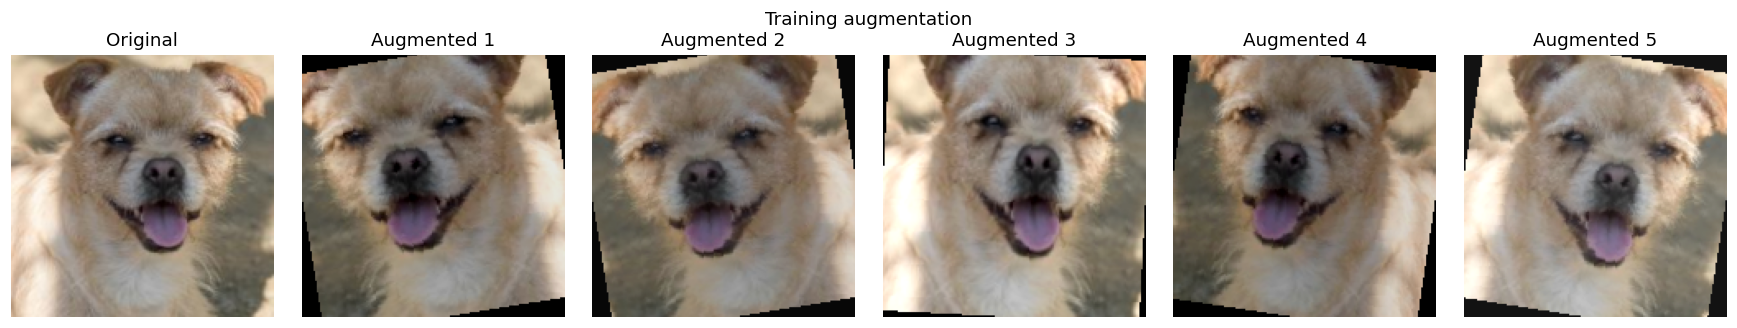

In [24]:
sample_img = cached_imgs[train_indices[0]]
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 6):
    aug = train_transform(sample_img) * STD + MEAN
    axes[i].imshow(aug.permute(1,2,0).clamp(0,1).numpy())
    axes[i].set_title(f"Augmented {i}"); axes[i].axis("off")
plt.suptitle("Training augmentation")
plt.tight_layout()
plt.savefig('chart_augmentation.png', bbox_inches='tight')
plt.show()

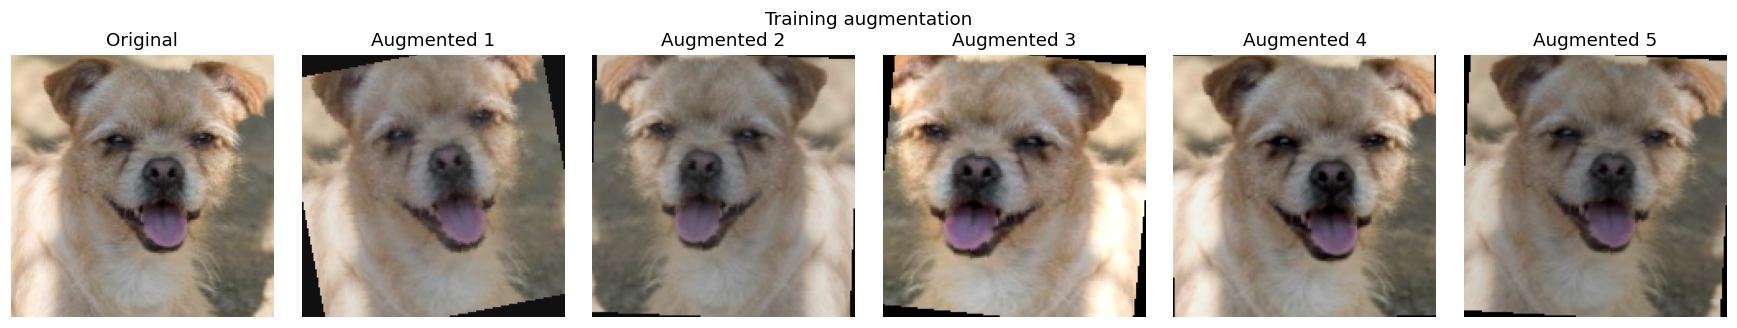

In [26]:
sample_img = cached_imgs[train_indices[0]]
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 6):
    aug = train_transform(sample_img) * STD + MEAN
    axes[i].imshow(aug.permute(1,2,0).clamp(0,1).numpy())
    axes[i].set_title(f"Augmented {i}"); axes[i].axis("off")
plt.suptitle("Training augmentation")
plt.tight_layout()
plt.savefig('chart_augmentation.png', bbox_inches='tight')
plt.show()

In [27]:
train_ds = DogTripletDataset(cached_imgs, cached_labels, train_indices, train_transform)
val_ds   = DogTripletDataset(cached_imgs, cached_labels, val_indices,   test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Training samples:", len(train_ds))
print("Batches per epoch:", len(train_loader))
print("Validation samples:", len(val_ds))


Training samples: 5823
Batches per epoch: 181
Validation samples: 811


In [28]:
criterion = nn.TripletMarginLoss(margin=TRIPLET_MARGIN, p=2)
print(f"Loss: TripletMarginLoss(margin={TRIPLET_MARGIN})")

Loss: TripletMarginLoss(margin=0.4)


In [29]:
def train_model(backbone_name, epochs=EPOCHS):
    model     = DogEmbeddingNet(backbone_name).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": []}
    best_val, best_state, stale = float("inf"), None, 0
    start = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch_num, (anchor, positive, negative) in enumerate(train_loader):
            anchor   = anchor.to(DEVICE)
            positive = positive.to(DEVICE)
            negative = negative.to(DEVICE)

            emb_a = model(anchor)
            emb_p = model(positive)
            emb_n = model(negative)

            loss = criterion(emb_a, emb_p, emb_n)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if batch_num % 50 == 0:
                print(f"  Epoch {epoch+1} | Batch {batch_num}/{len(train_loader)} "
                      f"| Loss: {loss.item():.4f}")

        train_loss = total_loss / len(train_loader)

        # ---- validation ----
        model.eval()
        vtotal = 0
        with torch.no_grad():
            for a, p, n in val_loader:
                vtotal += criterion(model(a.to(DEVICE)),
                                    model(p.to(DEVICE)),
                                    model(n.to(DEVICE))).item()
        val_loss = vtotal / max(len(val_loader), 1)

        scheduler.step()
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ---- best checkpoint + early stopping ----
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale, flag = 0, "  <- best"
        else:
            stale += 1; flag = ""

        mins = (time.time() - start) / 60
        print(f"Epoch {epoch+1} done | train {train_loss:.4f} | val {val_loss:.4f} "
              f"| {mins:.1f} min{flag}")

        if stale >= PATIENCE:
            print(f"  early stop - no improvement for {PATIENCE} epochs")
            break

    model.load_state_dict(best_state)
    total_min = (time.time() - start) / 60
    print(f"  done in {total_min:.1f} min | best val loss {best_val:.4f}")
    return model, history, total_min

print("train_model ready")

train_model ready


In [30]:
test_by_dog = {}
for i in test_indices:
    lbl = int(cached_labels[i])
    test_by_dog.setdefault(lbl, []).append(i)

test_valid = [d for d, imgs in test_by_dog.items() if len(imgs) >= 2]
print("Test dogs with 2+ photos:", len(test_valid))

Test dogs with 2+ photos: 268


In [31]:
import random
random.seed(123)

pairs = []

# Same dog pairs
for dog in test_valid:
    photos = test_by_dog[dog]
    for _ in range(2):
        a, b = random.sample(photos, 2)
        pairs.append((a, b, 1))

# Different dog pairs
for _ in range(len(pairs)):
    d1, d2 = random.sample(test_valid, 2)
    a = random.choice(test_by_dog[d1])
    b = random.choice(test_by_dog[d2])
    pairs.append((a, b, 0))

random.shuffle(pairs)
print("Total pairs:", len(pairs))
print("Same-dog pairs:", sum(1 for p in pairs if p[2] == 1))
print("Different-dog pairs:", sum(1 for p in pairs if p[2] == 0))

Total pairs: 1072
Same-dog pairs: 536
Different-dog pairs: 536


In [32]:
@torch.no_grad()
def measure_inference_ms(model, runs=50):
    model.eval()
    x = test_transform(cached_imgs[test_indices[0]]).unsqueeze(0).to(DEVICE)
    for _ in range(10):
        model(x)
    t0 = time.time()
    for _ in range(runs):
        model(x)
    return (time.time() - t0) / runs * 1000


@torch.no_grad()
def evaluate_model(model):
    model.eval()

    positions = sorted({p for a, b, _ in pairs for p in (a, b)})
    emb = {}
    for i in range(0, len(positions), 64):
        chunk = positions[i:i+64]
        x = torch.stack([test_transform(cached_imgs[p]) for p in chunk]).to(DEVICE)
        for p, v in zip(chunk, model(x).cpu().numpy()):
            emb[p] = v

    sims  = np.array([float(np.dot(emb[a], emb[b])) for a, b, _ in pairs])
    trues = np.array([s for _, _, s in pairs])

    best_threshold, best_accuracy = 0, 0
    for t in np.arange(0.0, 1.0, 0.01):
        acc = ((sims >= t).astype(int) == trues).mean()
        if acc > best_accuracy:
            best_accuracy, best_threshold = acc, t

    preds = (sims >= best_threshold).astype(int)
    TP = int(((preds == 1) & (trues == 1)).sum())
    TN = int(((preds == 0) & (trues == 0)).sum())
    FP = int(((preds == 1) & (trues == 0)).sum())
    FN = int(((preds == 0) & (trues == 1)).sum())

    precision = TP / (TP + FP) if TP + FP else 0
    recall    = TP / (TP + FN) if TP + FN else 0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0

    return {"sims": sims, "trues": trues,
            "threshold": float(best_threshold), "accuracy": float(best_accuracy),
            "precision": precision, "recall": recall, "f1": f1,
            "TP": TP, "TN": TN, "FP": FP, "FN": FN,
            "inference_ms": measure_inference_ms(model),
            "params_m": count_params(model)}

print("Evaluation ready")

Evaluation ready


In [33]:
results, histories, trained = {}, {}, {}

for name in MODELS:
    print(f"\n{'='*60}\nTRAINING {name}\n{'='*60}")
    model, hist, mins = train_model(name)

    print("  evaluating...")
    res = evaluate_model(model)
    res["train_minutes"] = mins

    results[name], histories[name], trained[name] = res, hist, model
    torch.save(model.state_dict(), f"model_{name}.pth")

    print(f"  accuracy {res['accuracy']*100:.2f}% | precision {res['precision']*100:.2f}% "
          f"| recall {res['recall']*100:.2f}% | F1 {res['f1']*100:.2f}%")
    print(f"  threshold {res['threshold']:.2f} | inference {res['inference_ms']:.1f} ms")


TRAINING resnet18
  Epoch 1 | Batch 0/181 | Loss: 0.2304
  Epoch 1 | Batch 50/181 | Loss: 0.0605
  Epoch 1 | Batch 100/181 | Loss: 0.0183
  Epoch 1 | Batch 150/181 | Loss: 0.0482
Epoch 1 done | train 0.0531 | val 0.0245 | 11.9 min  <- best
  Epoch 2 | Batch 0/181 | Loss: 0.0483
  Epoch 2 | Batch 50/181 | Loss: 0.0274
  Epoch 2 | Batch 100/181 | Loss: 0.0549
  Epoch 2 | Batch 150/181 | Loss: 0.0235
Epoch 2 done | train 0.0281 | val 0.0301 | 23.9 min
  Epoch 3 | Batch 0/181 | Loss: 0.0329
  Epoch 3 | Batch 50/181 | Loss: 0.0073
  Epoch 3 | Batch 100/181 | Loss: 0.0299
  Epoch 3 | Batch 150/181 | Loss: 0.0674
Epoch 3 done | train 0.0239 | val 0.0267 | 35.2 min
  Epoch 4 | Batch 0/181 | Loss: 0.0200
  Epoch 4 | Batch 50/181 | Loss: 0.0171
  Epoch 4 | Batch 100/181 | Loss: 0.0307
  Epoch 4 | Batch 150/181 | Loss: 0.0049
Epoch 4 done | train 0.0200 | val 0.0184 | 47.2 min  <- best
  Epoch 5 | Batch 0/181 | Loss: 0.0143
  Epoch 5 | Batch 50/181 | Loss: 0.0017
  Epoch 5 | Batch 100/181 | Loss

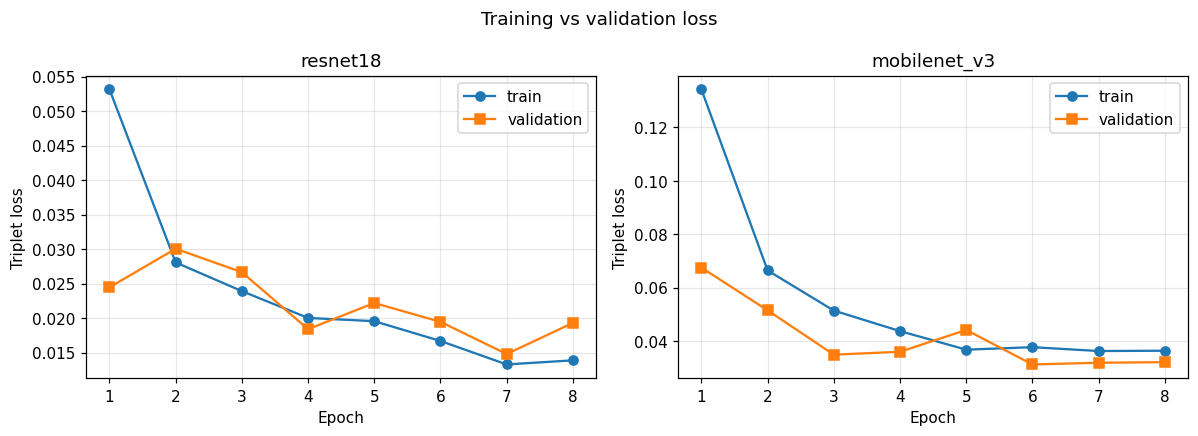

In [34]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5.5*len(MODELS), 4), squeeze=False)
for ax, name in zip(axes[0], MODELS):
    h = histories[name]
    ep = range(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], marker="o", label="train")
    ax.plot(ep, h["val_loss"],   marker="s", label="validation")
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("Triplet loss")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Training vs validation loss")
plt.tight_layout()
plt.savefig('chart_loss_curves.png', bbox_inches='tight')
plt.show()

       Model  Params (M)  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Threshold  Inference (ms)  Train (min)
    resnet18       11.24         94.87          93.49       96.46   94.95       0.55            35.4         94.4
mobilenet_v3        1.65         91.98          92.61       91.23   91.92       0.58            16.1         41.3

Best by accuracy : resnet18
Best by recall   : resnet18
Fastest          : mobilenet_v3
SELECTED         : mobilenet_v3


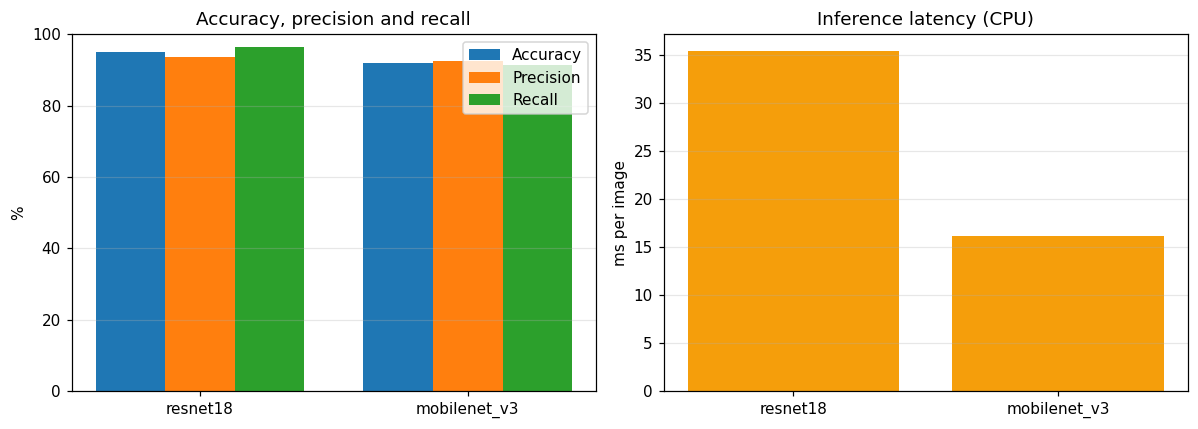

In [35]:
comparison = pd.DataFrame([{
    "Model": name,
    "Params (M)":     round(r["params_m"], 2),
    "Accuracy (%)":   round(r["accuracy"]*100, 2),
    "Precision (%)":  round(r["precision"]*100, 2),
    "Recall (%)":     round(r["recall"]*100, 2),
    "F1 (%)":         round(r["f1"]*100, 2),
    "Threshold":      r["threshold"],
    "Inference (ms)": round(r["inference_ms"], 1),
    "Train (min)":    round(r["train_minutes"], 1),
} for name, r in results.items()])

print(comparison.to_string(index=False))
comparison.to_csv("model_comparison.csv", index=False)

# weighted selection - recall matters most for a lost pet
sel = comparison.copy()
sel["Speed score"]   = (1 - sel["Inference (ms)"] / sel["Inference (ms)"].max()) * 100
sel["PetLink score"] = (0.35*sel["Accuracy (%)"] + 0.45*sel["Recall (%)"]
                        + 0.20*sel["Speed score"]).round(2)

best_model_name = sel.loc[sel["PetLink score"].idxmax(), "Model"]
print(f"\nBest by accuracy : {comparison.loc[comparison['Accuracy (%)'].idxmax(),'Model']}")
print(f"Best by recall   : {comparison.loc[comparison['Recall (%)'].idxmax(),'Model']}")
print(f"Fastest          : {comparison.loc[comparison['Inference (ms)'].idxmin(),'Model']}")
print(f"SELECTED         : {best_model_name}")

# comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(comparison)); w = 0.26
ax1.bar(x-w, comparison["Accuracy (%)"],  w, label="Accuracy")
ax1.bar(x,   comparison["Precision (%)"], w, label="Precision")
ax1.bar(x+w, comparison["Recall (%)"],    w, label="Recall")
ax1.set_xticks(x, comparison["Model"]); ax1.set_ylim(0,100); ax1.set_ylabel("%")
ax1.set_title("Accuracy, precision and recall"); ax1.legend(); ax1.grid(axis="y", alpha=0.3)
ax2.bar(comparison["Model"], comparison["Inference (ms)"], color="#F59E0B")
ax2.set_ylabel("ms per image"); ax2.set_title(f"Inference latency ({DEVICE.type.upper()})")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig('chart_model_comparison.png', bbox_inches='tight')
plt.show()

In [36]:
model = trained[best_model_name]
r     = results[best_model_name]
sims  = r["sims"]
trues = r["trues"]
best_threshold = r["threshold"]
best_accuracy  = r["accuracy"]

print(f"Using {best_model_name} for the remaining analysis")

Using mobilenet_v3 for the remaining analysis


In [39]:
same_sims = sims[trues == 1]
diff_sims = sims[trues == 0]

print("SAME dog pairs:")
print(f"  Average similarity: {same_sims.mean():.4f}")
print(f"  Min: {same_sims.min():.4f}  Max: {same_sims.max():.4f}")

print("\nDIFFERENT dog pairs:")
print(f"  Average similarity: {diff_sims.mean():.4f}")
print(f"  Min: {diff_sims.min():.4f}  Max: {diff_sims.max():.4f}")

print(f"\nGap between averages: {same_sims.mean() - diff_sims.mean():.4f}")

SAME dog pairs:
  Average similarity: 0.7875
  Min: -0.4962  Max: 0.9801

DIFFERENT dog pairs:
  Average similarity: 0.0418
  Min: -0.6999  Max: 0.8471

Gap between averages: 0.7457


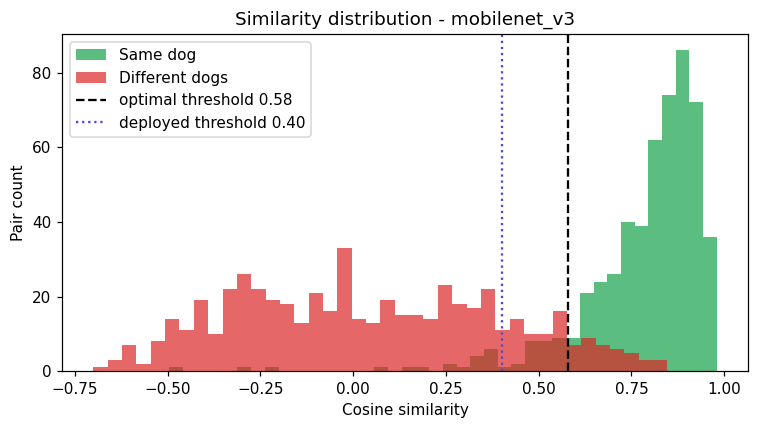

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(same_sims, bins=40, alpha=0.7, label="Same dog",       color="#16A34A")
ax.hist(diff_sims, bins=40, alpha=0.7, label="Different dogs", color="#DC2626")
ax.axvline(best_threshold, color="black", linestyle="--",
           label=f"optimal threshold {best_threshold:.2f}")
ax.axvline(0.40, color="#4F46E5", linestyle=":", label="deployed threshold 0.40")
ax.set_xlabel("Cosine similarity"); ax.set_ylabel("Pair count")
ax.set_title(f"Similarity distribution - {best_model_name}")
ax.legend(); plt.tight_layout()
plt.savefig('chart_similarity_distribution.png', bbox_inches='tight')
plt.show()

In [41]:
sel = comparison.copy()
W_ACC, W_REC, W_SPEED = 0.45, 0.45, 0.10

min_ms, max_ms = sel['Inference (ms)'].min(), sel['Inference (ms)'].max()
sel['Speed score'] = (1 - (sel['Inference (ms)'] - min_ms) / (max_ms - min_ms)) * 100
sel['PetLink score'] = (W_ACC * sel['Accuracy (%)'] +
                        W_REC * sel['Recall (%)'] +
                        W_SPEED * sel['Speed score']).round(2)

best_model_name = sel.loc[sel['PetLink score'].idxmax(), 'Model']
print(sel[['Model','Accuracy (%)','Recall (%)','Inference (ms)','PetLink score']]
      .to_string(index=False))
print(f'\nSELECTED: {best_model_name}')

model = trained[best_model_name]
r     = results[best_model_name]
sims, trues = r['sims'], r['trues']
best_threshold, best_accuracy = r['threshold'], r['accuracy']

       Model  Accuracy (%)  Recall (%)  Inference (ms)  PetLink score
    resnet18         94.87       96.46            35.4          86.10
mobilenet_v3         91.98       91.23            16.1          92.44

SELECTED: mobilenet_v3


In [42]:
sel = comparison.copy()
W_ACC, W_REC, W_SPEED = 0.45, 0.45, 0.10

min_ms, max_ms = sel['Inference (ms)'].min(), sel['Inference (ms)'].max()
sel['Speed score'] = (1 - (sel['Inference (ms)'] - min_ms) / (max_ms - min_ms)) * 100
sel['PetLink score'] = (W_ACC * sel['Accuracy (%)'] +
                        W_REC * sel['Recall (%)'] +
                        W_SPEED * sel['Speed score']).round(2)

best_model_name = sel.loc[sel['PetLink score'].idxmax(), 'Model']
print(f'SELECTED: {best_model_name}')

model = trained[best_model_name]
r     = results[best_model_name]
sims, trues = r['sims'], r['trues']
best_threshold, best_accuracy = r['threshold'], r['accuracy']

SELECTED: mobilenet_v3


In [43]:
print(comparison)
print()
print(comparison.dtypes)

          Model  Params (M)  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  \
0      resnet18       11.24         94.87          93.49       96.46   94.95   
1  mobilenet_v3        1.65         91.98          92.61       91.23   91.92   

   Threshold  Inference (ms)  Train (min)  
0       0.55            35.4         94.4  
1       0.58            16.1         41.3  

Model              object
Params (M)        float64
Accuracy (%)      float64
Precision (%)     float64
Recall (%)        float64
F1 (%)            float64
Threshold         float64
Inference (ms)    float64
Train (min)       float64
dtype: object


In [44]:
best_model_name = comparison.loc[comparison['Accuracy (%)'].idxmax(), 'Model']

print(f'SELECTED: {best_model_name}')
print(comparison.to_string(index=False))

model = trained[best_model_name]
r     = results[best_model_name]
sims, trues = r['sims'], r['trues']
best_threshold, best_accuracy = r['threshold'], r['accuracy']

print(f'\nUsing {best_model_name}:')
print(f"  accuracy  {r['accuracy']*100:.2f}%")
print(f"  precision {r['precision']*100:.2f}%")
print(f"  recall    {r['recall']*100:.2f}%")
print(f"  f1        {r['f1']*100:.2f}%")

SELECTED: resnet18
       Model  Params (M)  Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Threshold  Inference (ms)  Train (min)
    resnet18       11.24         94.87          93.49       96.46   94.95       0.55            35.4         94.4
mobilenet_v3        1.65         91.98          92.61       91.23   91.92       0.58            16.1         41.3

Using resnet18:
  accuracy  94.87%
  precision 93.49%
  recall    96.46%
  f1        94.95%


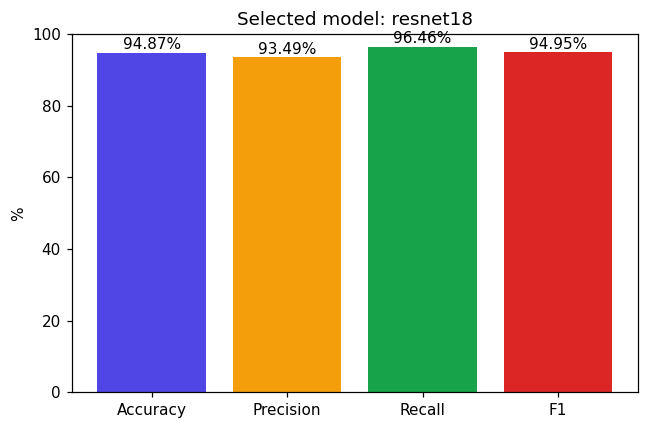

In [45]:
fig, ax = plt.subplots(figsize=(6, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
values  = [r['accuracy']*100, r['precision']*100, r['recall']*100, r['f1']*100]

bars = ax.bar(metrics, values, color=['#4F46E5', '#F59E0B', '#16A34A', '#DC2626'])
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.2f}%', ha='center', fontsize=10)

ax.set_ylim(0, 100)
ax.set_ylabel('%')
ax.set_title(f'Selected model: {best_model_name}')
plt.tight_layout()
plt.savefig('chart_selected_model_metrics.png', bbox_inches='tight')
plt.show()

In [47]:
model_v2, hist_v2, mins_v2 = train_model("resnet18", epochs=15)

print("  evaluating...")
res_v2 = evaluate_model(model_v2)
res_v2["train_minutes"] = mins_v2

print(f"\n{'='*60}")
print("COMPARISON")
print(f"{'='*60}")
print(f"Original (8 epochs)  : accuracy {results['resnet18']['accuracy']*100:.2f}%  "
      f"recall {results['resnet18']['recall']*100:.2f}%")
print(f"Tuned (15 epochs)    : accuracy {res_v2['accuracy']*100:.2f}%  "
      f"recall {res_v2['recall']*100:.2f}%")

if res_v2['accuracy'] > results['resnet18']['accuracy']:
    print("\nImproved - keeping the tuned model")
    results['resnet18_tuned'] = res_v2
    histories['resnet18_tuned'] = hist_v2
    trained['resnet18_tuned'] = model_v2
    torch.save(model_v2.state_dict(), 'model_resnet18_tuned.pth')
else:
    print("\nNo improvement - the 8-epoch model stays as the final choice")

  Epoch 1 | Batch 0/181 | Loss: 0.2733
  Epoch 1 | Batch 50/181 | Loss: 0.0410
  Epoch 1 | Batch 100/181 | Loss: 0.0155
  Epoch 1 | Batch 150/181 | Loss: 0.0337
Epoch 1 done | train 0.0533 | val 0.0308 | 12.4 min  <- best
  Epoch 2 | Batch 0/181 | Loss: 0.0546
  Epoch 2 | Batch 50/181 | Loss: 0.0121
  Epoch 2 | Batch 100/181 | Loss: 0.0081
  Epoch 2 | Batch 150/181 | Loss: 0.0070
Epoch 2 done | train 0.0282 | val 0.0219 | 24.4 min  <- best
  Epoch 3 | Batch 0/181 | Loss: 0.0137
  Epoch 3 | Batch 50/181 | Loss: 0.0256
  Epoch 3 | Batch 100/181 | Loss: 0.0087
  Epoch 3 | Batch 150/181 | Loss: 0.0268
Epoch 3 done | train 0.0233 | val 0.0297 | 36.1 min
  Epoch 4 | Batch 0/181 | Loss: 0.0158
  Epoch 4 | Batch 50/181 | Loss: 0.0060
  Epoch 4 | Batch 100/181 | Loss: 0.0619
  Epoch 4 | Batch 150/181 | Loss: 0.0389
Epoch 4 done | train 0.0209 | val 0.0298 | 47.9 min
  Epoch 5 | Batch 0/181 | Loss: 0.0247
  Epoch 5 | Batch 50/181 | Loss: 0.0050
  Epoch 5 | Batch 100/181 | Loss: 0.0135
  Epoch 5 

In [49]:
best_model_name = comparison.loc[comparison['Accuracy (%)'].idxmax(), 'Model']
print(f'SELECTED: {best_model_name}')

model = trained[best_model_name]
r     = results[best_model_name]
sims, trues = r['sims'], r['trues']
best_threshold, best_accuracy = r['threshold'], r['accuracy']

# ---- f1, recall, precision, accuracy ---- ⭐ මේ 4ම මෙතන print වෙනවා
print(f"\nFinal model: {best_model_name}")
print(f"  Accuracy  : {r['accuracy']*100:.2f}%")
print(f"  Precision : {r['precision']*100:.2f}%")
print(f"  Recall    : {r['recall']*100:.2f}%")
print(f"  F1 Score  : {r['f1']*100:.2f}%")
print(f"  Threshold : {best_threshold:.2f}")

SELECTED: resnet18

Final model: resnet18
  Accuracy  : 94.87%
  Precision : 93.49%
  Recall    : 96.46%
  F1 Score  : 94.95%
  Threshold : 0.55


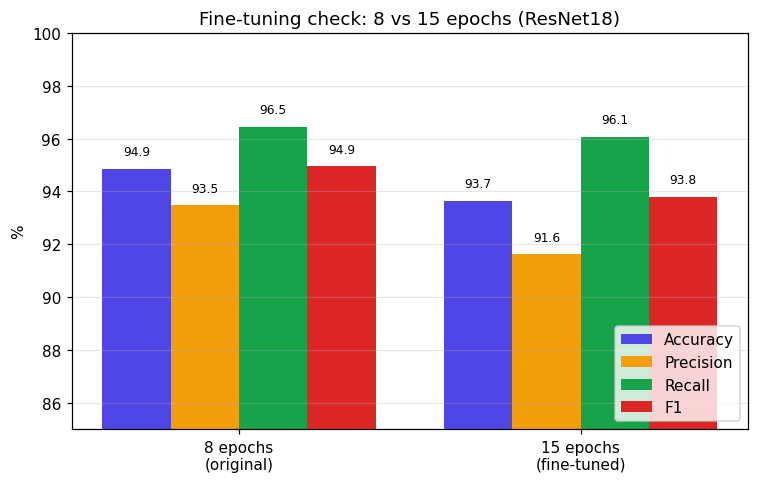

8 epochs  : 94.87% accuracy  <- selected
15 epochs : 93.66% accuracy

Conclusion: extending training did not improve results,
confirming the 8-epoch model had already converged.


In [50]:
fig, ax = plt.subplots(figsize=(7, 4.5))

labels = ['8 epochs\n(original)', '15 epochs\n(fine-tuned)']
acc    = [results['resnet18']['accuracy']*100, res_v2['accuracy']*100]
rec    = [results['resnet18']['recall']*100,   res_v2['recall']*100]
prec   = [results['resnet18']['precision']*100, res_v2['precision']*100]
f1     = [results['resnet18']['f1']*100,        res_v2['f1']*100]

x = np.arange(2); w = 0.2
ax.bar(x - 1.5*w, acc,  w, label='Accuracy',  color='#4F46E5')
ax.bar(x - 0.5*w, prec, w, label='Precision', color='#F59E0B')
ax.bar(x + 0.5*w, rec,  w, label='Recall',    color='#16A34A')
ax.bar(x + 1.5*w, f1,   w, label='F1',        color='#DC2626')

for i, vals in enumerate([acc, prec, rec, f1]):
    for j, v in enumerate(vals):
        ax.text(x[j] + (i-1.5)*w, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)

ax.set_xticks(x, labels)
ax.set_ylabel('%'); ax.set_ylim(85, 100)
ax.set_title('Fine-tuning check: 8 vs 15 epochs (ResNet18)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart_finetune_comparison.png', bbox_inches='tight')
plt.show()

print(f"8 epochs  : {acc[0]:.2f}% accuracy  <- selected")
print(f"15 epochs : {acc[1]:.2f}% accuracy")
print(f"\nConclusion: extending training did not improve results,")
print(f"confirming the 8-epoch model had already converged.")

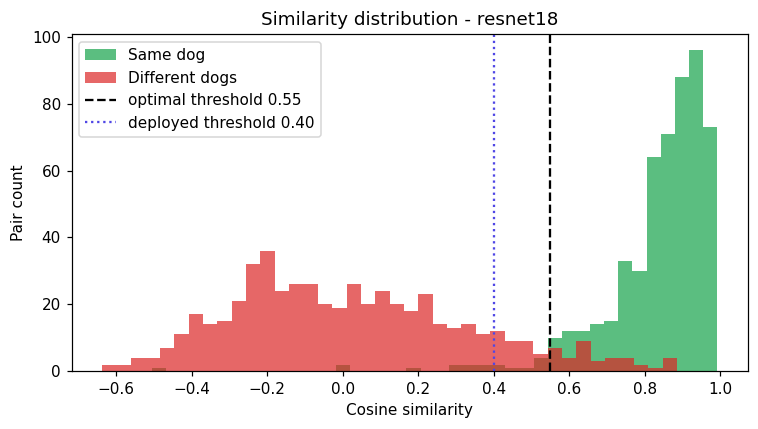

Same-dog mean      : 0.8363
Different-dog mean : 0.0233
Gap                : 0.8130


In [51]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims[trues == 1], bins=40, alpha=0.7, label="Same dog",       color="#16A34A")
ax.hist(sims[trues == 0], bins=40, alpha=0.7, label="Different dogs", color="#DC2626")
ax.axvline(best_threshold, color="black", linestyle="--",
           label=f"optimal threshold {best_threshold:.2f}")
ax.axvline(0.40, color="#4F46E5", linestyle=":", label="deployed threshold 0.40")
ax.set_xlabel("Cosine similarity"); ax.set_ylabel("Pair count")
ax.set_title(f"Similarity distribution - {best_model_name}")
ax.legend(); plt.tight_layout()
plt.savefig('chart_similarity_distribution.png', bbox_inches='tight')
plt.show()

print(f"Same-dog mean      : {sims[trues==1].mean():.4f}")
print(f"Different-dog mean : {sims[trues==0].mean():.4f}")
print(f"Gap                : {sims[trues==1].mean() - sims[trues==0].mean():.4f}")

TP: 517  TN: 500  FP: 36  FN: 19


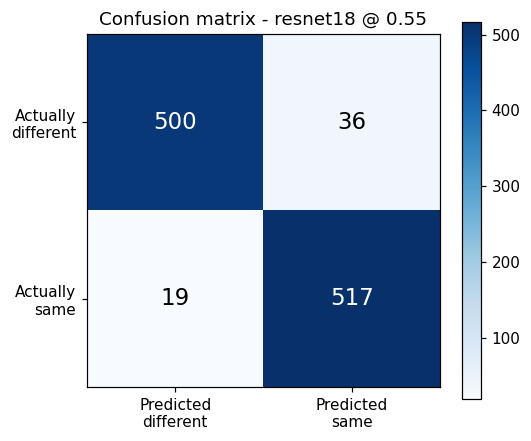

In [52]:
TP, TN, FP, FN = r['TP'], r['TN'], r['FP'], r['FN']
print(f"TP: {TP}  TN: {TN}  FP: {FP}  FN: {FN}")

cm = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1], ["Predicted\ndifferent", "Predicted\nsame"])
ax.set_yticks([0,1], ["Actually\ndifferent", "Actually\nsame"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=15,
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title(f"Confusion matrix - {best_model_name} @ {best_threshold:.2f}")
fig.colorbar(im); plt.tight_layout()
plt.savefig('chart_confusion_matrix.png', bbox_inches='tight')
plt.show()

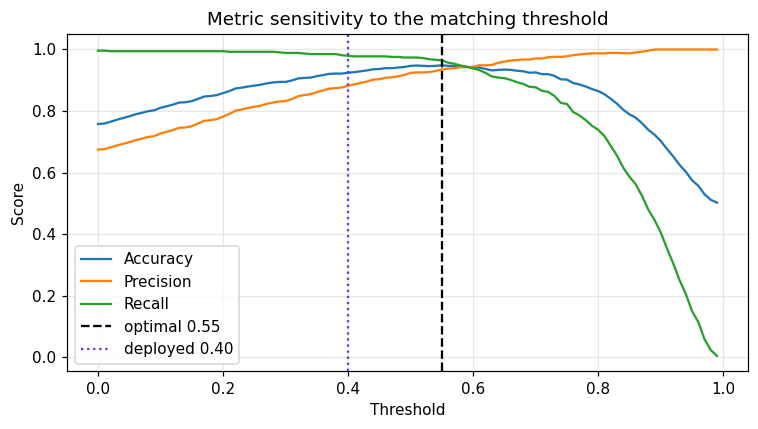

In [53]:
ts = np.arange(0.0, 1.0, 0.01)
acc_c, pre_c, rec_c = [], [], []
for t in ts:
    p  = (sims >= t).astype(int)
    tp = ((p==1)&(trues==1)).sum(); fp = ((p==1)&(trues==0)).sum(); fn = ((p==0)&(trues==1)).sum()
    acc_c.append((p == trues).mean())
    pre_c.append(tp/(tp+fp) if tp+fp else 0)
    rec_c.append(tp/(tp+fn) if tp+fn else 0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, acc_c, label="Accuracy")
ax.plot(ts, pre_c, label="Precision")
ax.plot(ts, rec_c, label="Recall")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"optimal {best_threshold:.2f}")
ax.axvline(0.40, color="#4F46E5", linestyle=":", label="deployed 0.40")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Metric sensitivity to the matching threshold")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('chart_threshold_curve.png', bbox_inches='tight')
plt.show()

YOLOv8n DETECTION METRICS
  Detection rate       : 36.5%
  Mean confidence      : 0.6625
  Mean inference       : 128.5 ms/image (CPU)

  mAP note: requires ground-truth bounding boxes, unavailable in this
  identity-labelled dataset. YOLOv8n's published COCO mAP50-95 is 37.3.


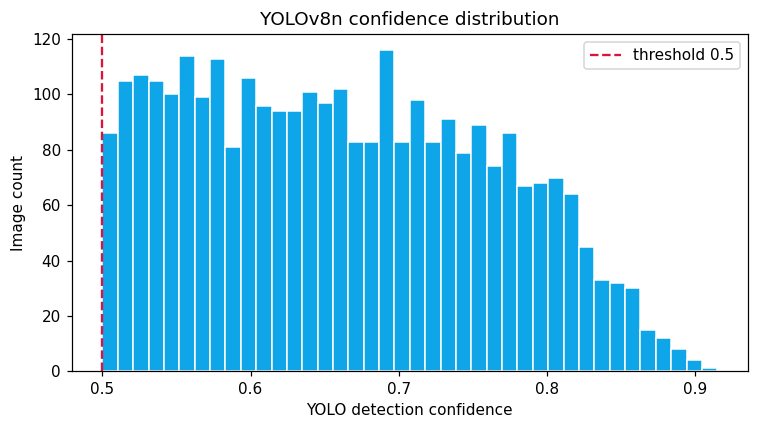

In [54]:
times = []
for p in test_indices[:100]:
    t0 = time.time()
    yolo(cached_imgs[p], verbose=False)
    times.append((time.time() - t0) * 1000)

print("YOLOv8n DETECTION METRICS")
print(f"  Detection rate       : {detected/len(keep_indices)*100:.1f}%")
print(f"  Mean confidence      : {np.mean(yolo_confs):.4f}")
print(f"  Mean inference       : {np.mean(times):.1f} ms/image ({DEVICE.type.upper()})")
print("\n  mAP note: requires ground-truth bounding boxes, unavailable in this")
print("  identity-labelled dataset. YOLOv8n's published COCO mAP50-95 is 37.3.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(yolo_confs, bins=40, color="#0EA5E9", edgecolor="white")
ax.axvline(YOLO_CONF, color="crimson", linestyle="--", label=f"threshold {YOLO_CONF}")
ax.set_xlabel("YOLO detection confidence"); ax.set_ylabel("Image count")
ax.set_title("YOLOv8n confidence distribution")
ax.legend(); plt.tight_layout()
plt.savefig('chart_yolo_confidence.png', bbox_inches='tight')
plt.show()

In [55]:
import os, json

torch.save(model.state_dict(), "dog_face_model.pth")

summary = {
    "best_model": best_model_name,
    "device": str(DEVICE),
    "image_size": IMG_SIZE,
    "results": {k: {m: v[m] for m in
                    ["accuracy","precision","recall","f1","threshold",
                     "inference_ms","params_m","train_minutes","TP","TN","FP","FN"]}
                for k, v in results.items() if k in ["resnet18", "mobilenet_v3"]},
}
with open("training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved dog_face_model.pth (backbone: {best_model_name})")
print(f"Size: {os.path.getsize('dog_face_model.pth') / 1024 / 1024:.1f} MB")
print(f"Path: {os.path.abspath('dog_face_model.pth')}")

Saved dog_face_model.pth (backbone: resnet18)
Size: 43.0 MB
Path: d:\OneDrive\Desktop\dog face model\dog_face_model.pth


Dog found with confidence 0.59


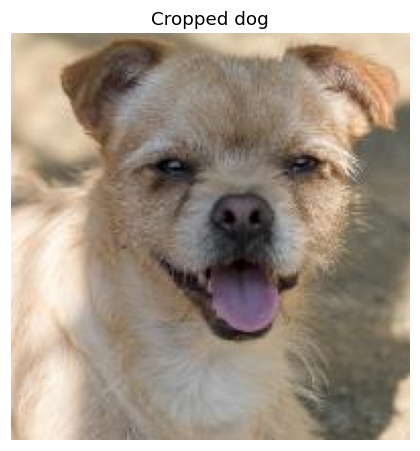

In [56]:
crop, conf = detect_and_crop_dog(img_array)

if crop is not None:
    print(f"Dog found with confidence {conf:.2f}")
    plt.imshow(crop)
    plt.axis("off")
    plt.title("Cropped dog")
    plt.show()
else:
    print("No dog detected")

In [57]:
import cv2

def process_video(video_path, num_frames=15):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total == 0:
        print("Could not read video")
        return []

    step = max(total // num_frames, 1)
    crops = []

    for i in range(0, total, step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, frame = cap.read()
        if not ok:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        crop, conf = detect_and_crop_dog(frame_rgb)

        if crop is not None:
            crops.append((crop, conf, i))

    cap.release()
    return crops

print("process_video ready")

process_video ready



Total crops: 4


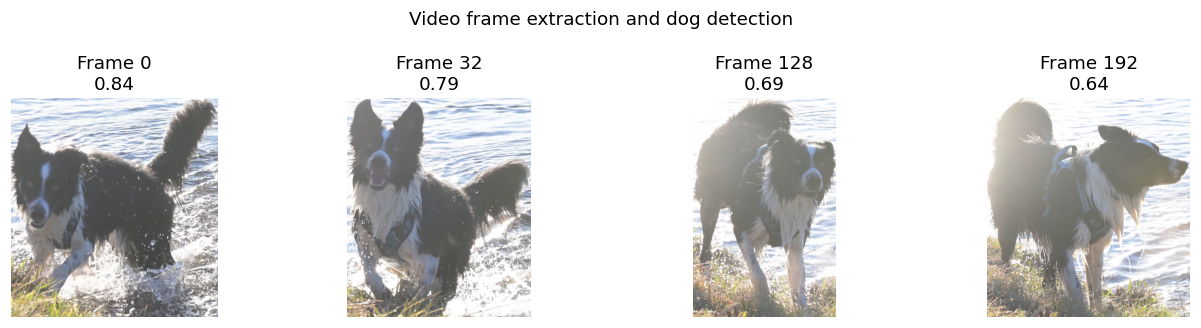

In [58]:
VIDEO_PATH = r"D:\OneDrive\Desktop\yoshi\dog face model\test_dog.mp4"

crops = process_video(VIDEO_PATH)
print(f"\nTotal crops: {len(crops)}")

if crops:
    show = crops[:6]
    fig, axes = plt.subplots(1, len(show), figsize=(3*len(show), 3))
    if len(show) == 1:
        axes = [axes]
    for ax, (crop, conf, frame_no) in zip(axes, show):
        ax.imshow(crop)
        ax.set_title(f"Frame {frame_no}\n{conf:.2f}")
        ax.axis("off")
    plt.suptitle("Video frame extraction and dog detection")
    plt.tight_layout()
    plt.savefig('chart_video_frames.png', bbox_inches='tight')
    plt.show()

In [59]:
from PIL import Image

def check_match(owner_photo, video_path, threshold=0.40, num_frames=15, top_k=5):
    model.eval()
    if isinstance(owner_photo, np.ndarray):
        owner_arr = owner_photo
    else:
        owner_arr = np.array(owner_photo.convert("RGB"))
    owner_arr = np.array(Image.fromarray(owner_arr).resize((IMG_SIZE, IMG_SIZE)))

    with torch.no_grad():
        owner_emb = model(test_transform(owner_arr).unsqueeze(0).to(DEVICE))

    crops = process_video(video_path, num_frames=num_frames)
    if not crops:
        print("No dog detected in video")
        return None

    best_sim, best_crop = -1, None
    for crop, conf, frame_no in crops:
        arr = np.array(Image.fromarray(crop).resize((IMG_SIZE, IMG_SIZE)))
        with torch.no_grad():
            e = model(test_transform(arr).unsqueeze(0).to(DEVICE))
        sim = F.cosine_similarity(owner_emb, e).item()
        if sim > best_sim:
            best_sim, best_crop = sim, crop

    top = sorted(crops, key=lambda c: c[1], reverse=True)[:top_k]
    embs = []
    for crop, conf, frame_no in top:
        arr = np.array(Image.fromarray(crop).resize((IMG_SIZE, IMG_SIZE)))
        with torch.no_grad():
            embs.append(model(test_transform(arr).unsqueeze(0).to(DEVICE)))
    avg_emb = F.normalize(torch.cat(embs).mean(dim=0, keepdim=True), p=2, dim=1)
    avg_sim = F.cosine_similarity(owner_emb, avg_emb).item()

    print(f"Frames with a dog     : {len(crops)}")
    print(f"Best single frame     : {best_sim:.4f}")
    print(f"Average of top {top_k}     : {avg_sim:.4f}")
    print(f"Verdict @ {threshold}       : "
          f"{'MATCH - send email' if avg_sim >= threshold else 'NO MATCH'}")

    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(owner_arr); ax[0].set_title("Owner's photo"); ax[0].axis("off")
    ax[1].imshow(best_crop); ax[1].set_title("Best video frame"); ax[1].axis("off")
    plt.suptitle(f"Averaged similarity: {avg_sim:.3f}")
    plt.tight_layout()
    plt.savefig('chart_video_match.png', bbox_inches='tight')
    plt.show()

    return {"best_single": best_sim, "avg_top_k": avg_sim,
            "frames": len(crops), "match": avg_sim >= threshold}

Frames with a dog     : 4
Best single frame     : 0.1449
Average of top 5     : 0.0008
Verdict @ 0.4       : NO MATCH


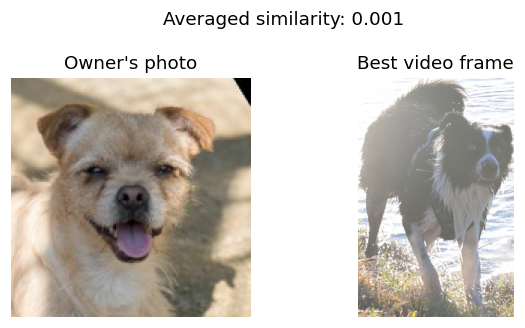

In [60]:
owner_photo = train[0]["image"]
result = check_match(owner_photo, VIDEO_PATH)

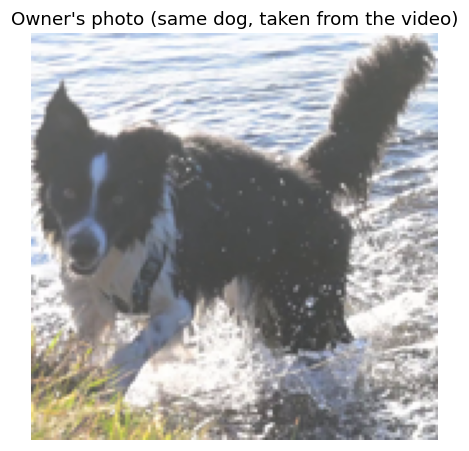

Frames with a dog     : 4
Best single frame     : 1.0000
Average of top 5     : 0.9350
Verdict @ 0.4       : MATCH - send email


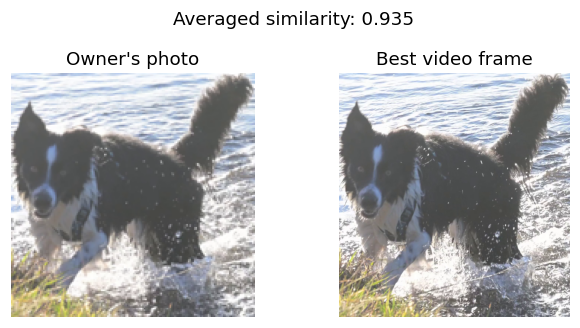

In [61]:
owner_photo_from_video = Image.fromarray(crops[0][0]).resize((IMG_SIZE, IMG_SIZE))
plt.imshow(owner_photo_from_video)
plt.title("Owner's photo (same dog, taken from the video)")
plt.axis("off")
plt.show()

result = check_match(owner_photo_from_video, VIDEO_PATH)